# Learning Day 4: Outlier Detection

## Step 1 — Load the Industrial Equipment Monitoring Dataset

In this project, we are working on **outlier detection**.

An outlier means one unusual row in the dataset.  
For example, if most machine temperature values are around 70–80°C, but one row shows 180°C, that row may be suspicious.

In this first step, we will:

1. Import the required Python libraries.
2. Set important constants such as `RANDOM_STATE` and `Z_SCORE_THRESHOLD`.
3. Download the dataset from KaggleHub.
4. Find the CSV file automatically without hardcoding one fixed path.
5. Load the dataset into a pandas DataFrame.
6. Preview the first few rows.

We are not detecting outliers yet.  
This step is only for clean setup and dataset loading.

In [7]:
# ============================================================
# Learning Day 4: Outlier Detection
# Cell 1: Load the dataset
# ============================================================

# pandas is used to load and work with tabular data
import pandas as pd

# numpy will be used later for numerical calculations
import numpy as np

# matplotlib and seaborn will be used later for visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Project constants
RANDOM_STATE = 42
Z_SCORE_THRESHOLD = 3.0

# CSV file path
# Keep the CSV file in the same folder as this notebook.
DATA_PATH = "equipment_anomaly_data.csv"

# Load the dataset into a pandas DataFrame
df = pd.read_csv(DATA_PATH)

# Show basic dataset information
print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows and {df.shape[1]} columns")

# Preview the first 5 rows
display(df.head())

# Show column names, data types, and non-null counts
df.info()

Dataset loaded successfully.
Shape: 7672 rows and 7 columns


,temperature,pressure,vibration,humidity,equipment,location,faulty
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0


<class 'pandas.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   str    
 5   location     7672 non-null   str    
 6   faulty       7672 non-null   float64
dtypes: float64(5), str(2)
memory usage: 419.7 KB


## Step 2 — Understand the Dataset Structure

Before detecting outliers, we first identify which columns are useful for statistical outlier detection.

For the beginner Z-Score method, we only use numerical sensor columns such as:

- temperature
- pressure
- vibration
- humidity

We exclude the `faulty` column because it is a label/target column, not a sensor measurement.

In this step, we will check:

1. column names
2. data types
3. missing values
4. duplicate rows
5. numerical sensor columns for Z-Score analysis

In [8]:
# ============================================================
# Cell 2: Basic dataset inspection
# ============================================================

# Show all column names
print("Column names:")
print(df.columns.tolist())

print("\n" + "="*60)

# Show data types of each column
print("Data types:")
display(df.dtypes)

print("\n" + "="*60)

# Check missing values in each column
print("Missing values per column:")
display(df.isnull().sum())

print("\n" + "="*60)

# Check duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

print("\n" + "="*60)

# Identify numerical columns automatically
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove the target/label column from numerical sensor columns
# 'faulty' tells us whether equipment is faulty, but it is not a sensor measurement.
sensor_columns = [col for col in numeric_columns if col != "faulty"]

print("Numerical columns found:")
print(numeric_columns)

print("\nSensor columns selected for Z-Score outlier detection:")
print(sensor_columns)

print("\n" + "="*60)

# Show basic statistics for the selected sensor columns
print("Basic statistics for sensor columns:")
display(df[sensor_columns].describe().T)

Column names:
['temperature', 'pressure', 'vibration', 'humidity', 'equipment', 'location', 'faulty']

Data types:


temperature    float64
pressure       float64
vibration      float64
humidity       float64
equipment          str
location           str
faulty         float64
dtype: object


Missing values per column:


temperature    0
pressure       0
vibration      0
humidity       0
equipment      0
location       0
faulty         0
dtype: int64


Number of duplicate rows: 0

Numerical columns found:
['temperature', 'pressure', 'vibration', 'humidity', 'faulty']

Sensor columns selected for Z-Score outlier detection:
['temperature', 'pressure', 'vibration', 'humidity']

Basic statistics for sensor columns:


,count,mean,std,min,25%,50%,75%,max
temperature,7672.0,70.922478,16.200059,10.269385,62.777057,70.156900,77.568387,149.690420
pressure,7672.0,35.738048,10.381593,3.620798,29.485682,35.227544,41.159913,79.887734
vibration,7672.0,1.611809,0.728560,-0.428188,1.170906,1.533113,1.924700,4.990537
humidity,7672.0,50.016574,11.841479,10.215077,42.612817,50.024744,57.340513,89.984718


### Step 2 Conclusion — Dataset Structure Check

The dataset was loaded correctly and contains **7,672 rows and 7 columns**.

There are **no missing values** and **no duplicate rows**, so no basic cleaning is required at this stage.

The dataset contains four numerical sensor columns:

- `temperature`
- `pressure`
- `vibration`
- `humidity`

These columns will be used for Z-Score based outlier detection because they represent actual machine measurements.

The column `faulty` is also numerical, but it is not used for Z-Score detection because it is the target/label column.  
It tells us whether the equipment was faulty (`1`) or not faulty (`0`), so it is the answer, not the sensor evidence.

From the summary statistics, the sensor columns show some wide value ranges, especially:

- `temperature`: from about **10.27** to **149.69**
- `pressure`: from about **3.62** to **79.89**
- `vibration`: from about **-0.43** to **4.99**
- `humidity`: from about **10.22** to **89.98**

These wide ranges suggest that some rows may contain unusual sensor readings.  
In the next step, we will calculate Z-Scores for the sensor columns and mark rows as statistical outliers when at least one sensor value is more than 3 standard deviations away from its mean.

## Step 3 — Calculate Z-Scores and Detect Statistical Outliers

Now we start the actual beginner outlier detection task.

A **Z-Score** tells us how far a sensor value is from the average value of that sensor column.

For example:

- a Z-Score near `0` means the value is close to normal
- a Z-Score of `2` means the value is 2 standard deviations away from the mean
- a Z-Score greater than `3` or less than `-3` is usually treated as unusual

In this step, we will:

1. calculate the Z-Score for each sensor column
2. check whether any sensor value has `absolute Z-Score > 3`
3. create a new column called `zscore_outlier`
4. count how many rows are detected as statistical outliers

We use only the sensor columns:

- `temperature`
- `pressure`
- `vibration`
- `humidity`

We do not use `faulty` here because it is the label/answer column.

In [11]:
# ============================================================
# Cell 3A: Create a safe copy for Z-Score analysis
# ============================================================

# We create a copy so the original dataframe `df` stays unchanged.
# All Z-Score columns and outlier flags will be added to this copy.
df_zscore = df.copy()

print("Copy created successfully.")
print(f"Original dataframe shape: {df.shape}")
print(f"Z-Score dataframe shape: {df_zscore.shape}")

Copy created successfully.
Original dataframe shape: (7672, 7)
Z-Score dataframe shape: (7672, 7)


In [12]:
# ============================================================
# Cell 3B: Calculate Z-Scores for sensor columns
# ============================================================

# Z-Score formula:
# z = (value - column_mean) / column_standard_deviation

z_scores = (
    df_zscore[sensor_columns] - df_zscore[sensor_columns].mean()
) / df_zscore[sensor_columns].std()

print("Z-Scores calculated successfully.")
print(f"Z-Score table shape: {z_scores.shape}")

display(z_scores.head())

Z-Scores calculated successfully.
Z-Score table shape: (7672, 4)


,temperature,pressure,vibration,humidity
0,-0.786559,-1.031515,-1.379835,-0.364960
1,0.297421,-1.231413,0.996878,-0.688188
2,0.026921,-0.815021,-0.305549,0.754790
3,0.042871,-0.336666,0.218075,-0.798163
4,-0.272570,0.911173,-1.738238,-0.571109


### Cell 3B Conclusion — Z-Scores Calculated

The Z-Scores were calculated successfully for the selected sensor columns:

- `temperature`
- `pressure`
- `vibration`
- `humidity`

A Z-Score tells us how far each value is from the average of its own column.

For example:

- a Z-Score close to `0` means the value is close to the column average
- a positive Z-Score means the value is above the column average
- a negative Z-Score means the value is below the column average
- an absolute Z-Score greater than `3` is usually considered statistically unusual

From the first five rows, the Z-Score values are mostly between about `-1.7` and `1.0`.

This means the first few rows are not statistical outliers according to the rule:

`absolute Z-Score > 3`

In the next step, we will add these Z-Score values back to the main working dataframe so that each original sensor value can be seen together with its calculated Z-Score.

In [13]:
# ============================================================
# Cell 3C: Add Z-Score columns to the dataframe
# ============================================================

# Create clear column names for the Z-Score values.
# Example:
# temperature -> temperature_zscore
z_score_columns = [f"{col}_zscore" for col in sensor_columns]

# Rename the Z-Score dataframe columns.
z_scores.columns = z_score_columns

# Add the Z-Score columns to df_zscore.
# This lets us compare original sensor values and their Z-Scores side by side.
df_zscore = pd.concat([df_zscore, z_scores], axis=1)

print("Z-Score columns added successfully.")
print(f"Updated dataframe shape: {df_zscore.shape}")

display(df_zscore.head())

Z-Score columns added successfully.
Updated dataframe shape: (7672, 11)


,temperature,pressure,vibration,humidity,equipment,location,faulty,temperature_zscore,pressure_zscore,vibration_zscore,humidity_zscore
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0,-0.786559,-1.031515,-1.379835,-0.364960
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0,0.297421,-1.231413,0.996878,-0.688188
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0,0.026921,-0.815021,-0.305549,0.754790
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0,0.042871,-0.336666,0.218075,-0.798163
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0,-0.272570,0.911173,-1.738238,-0.571109


### Cell 3C Conclusion — Z-Score Columns Added

The calculated Z-Score columns were added successfully to the working dataframe `df_zscore`.

The new columns are:

- `temperature_zscore`
- `pressure_zscore`
- `vibration_zscore`
- `humidity_zscore`

Now each row contains both:

1. the original sensor value  
2. the Z-Score version of that sensor value

This is useful because we can compare the real sensor reading with how unusual it is statistically.

For example, in the first row:

- `temperature = 58.18`
- `temperature_zscore = -0.79`

This means the temperature value is below the average temperature, but not extremely unusual.

At this stage, we have only calculated and attached the Z-Scores.  
In the next step, we will create an outlier flag that marks a row as an outlier if **any sensor column** has:

`absolute Z-Score > 3`

## Step 3D — Mark Rows as Z-Score Outliers

Now that we have calculated Z-Scores for each sensor column, we will create an outlier flag.

A row will be marked as an outlier if **at least one sensor column** has:

`absolute Z-Score > 3`

We use the absolute value because both extremely high and extremely low readings can be unusual.

Example:

- very high temperature → possible outlier
- very low pressure → possible outlier
- very high vibration → possible outlier

The new column will be called:

`zscore_outlier`

It will contain:

- `True` = row is a statistical outlier
- `False` = row is not a statistical outlier

In [14]:
# ============================================================
# Cell 3D: Mark rows as Z-Score outliers
# ============================================================

# A row is an outlier if ANY sensor Z-Score is greater than 3
# or less than -3.
#
# abs() converts negative Z-Scores into positive distances.
# Example:
# -3.5 becomes 3.5
#  3.5 stays 3.5

df_zscore["zscore_outlier"] = (
    df_zscore[z_score_columns].abs() > Z_SCORE_THRESHOLD
).any(axis=1)

# Count how many rows are marked as outliers
outlier_count = df_zscore["zscore_outlier"].sum()

# Count total rows
total_rows = len(df_zscore)

# Calculate percentage of outlier rows
outlier_percentage = (outlier_count / total_rows) * 100

print("Z-Score outlier flag created successfully.")
print(f"Threshold used: absolute Z-Score > {Z_SCORE_THRESHOLD}")
print(f"Total rows: {total_rows}")
print(f"Outlier rows detected: {outlier_count}")
print(f"Outlier percentage: {outlier_percentage:.2f}%")

# Preview the outlier flag
display(df_zscore[["temperature", "pressure", "vibration", "humidity", "zscore_outlier"]].head())

Z-Score outlier flag created successfully.
Threshold used: absolute Z-Score > 3.0
Total rows: 7672
Outlier rows detected: 467
Outlier percentage: 6.09%


,temperature,pressure,vibration,humidity,zscore_outlier
0,58.180180,25.029278,0.606516,45.694907,False
1,75.740712,22.954018,2.338095,41.867407,False
2,71.358594,27.276830,1.389198,58.954409,False
3,71.616985,32.242921,1.770690,40.565138,False
4,66.506832,45.197471,0.345398,43.253795,False


### Cell 3D Conclusion — Z-Score Outliers Detected

Using the rule `absolute Z-Score > 3`, the dataset contains **467 statistical outlier rows** out of **7,672 total rows**.

This means approximately **6.09%** of the dataset is marked as outlier using the Z-Score method.

A row was marked as an outlier if at least one of the following sensor columns had an unusually high or low Z-Score:

- `temperature`
- `pressure`
- `vibration`
- `humidity`

The first five rows are not outliers because their sensor values are still within the normal statistical range.

This does not automatically mean the 467 rows should be deleted.  
It only means these rows contain unusual sensor readings and should be inspected further.

In the next step, we will check which sensor columns are responsible for these Z-Score outliers.

## Step 3E — Identify Which Sensor Columns Caused the Outliers

We already know that **467 rows** were marked as Z-Score outliers.

Now we want to understand **why** those rows were marked as outliers.

A row can be an outlier because of:

- unusually high or low `temperature`
- unusually high or low `pressure`
- unusually high or low `vibration`
- unusually high or low `humidity`
- or more than one unusual sensor at the same time

In this step, we count how many outliers each sensor column contributes.

In [15]:
# ============================================================
# Cell 3E: Count which sensor columns caused Z-Score outliers
# ============================================================

# Create a boolean table showing whether each sensor Z-Score
# crosses the outlier threshold.
#
# True  = this sensor is unusual for that row
# False = this sensor is not unusual for that row
zscore_outlier_flags = df_zscore[z_score_columns].abs() > Z_SCORE_THRESHOLD

# Count how many times each sensor column crosses the threshold.
zscore_outlier_counts = zscore_outlier_flags.sum().sort_values(ascending=False)

print("Number of Z-Score outliers by sensor column:")
display(zscore_outlier_counts)

# Convert counts to percentage of total rows.
zscore_outlier_percentages = (
    zscore_outlier_counts / len(df_zscore) * 100
).round(2)

print("\nPercentage of total rows flagged by each sensor column:")
display(zscore_outlier_percentages)

Number of Z-Score outliers by sensor column:


temperature_zscore    235
vibration_zscore      193
pressure_zscore       123
humidity_zscore        96
dtype: int64


Percentage of total rows flagged by each sensor column:


temperature_zscore    3.06
vibration_zscore      2.52
pressure_zscore       1.60
humidity_zscore       1.25
dtype: float64

### Cell 3E Conclusion — Sensor Contribution to Z-Score Outliers

The Z-Score outlier analysis shows that the outliers are not caused equally by all sensor columns.

The number of threshold crossings by sensor is:

- `temperature_zscore`: **235**
- `vibration_zscore`: **193**
- `pressure_zscore`: **123**
- `humidity_zscore`: **96**

This means `temperature` contributes the most to the detected Z-Score outliers, followed by `vibration`.

Important note: these counts can add up to more than the total number of outlier rows because one row can be unusual in more than one sensor column at the same time.

For example, a single row could have both:

- unusually high temperature
- unusually high vibration

So it would be counted under both `temperature_zscore` and `vibration_zscore`.

From a machine monitoring perspective, this is useful because it suggests that unusual equipment behavior is most visible in `temperature` and `vibration`.

In the next step, we will create a professional chart to visualize which sensor columns contribute most to the Z-Score outliers.

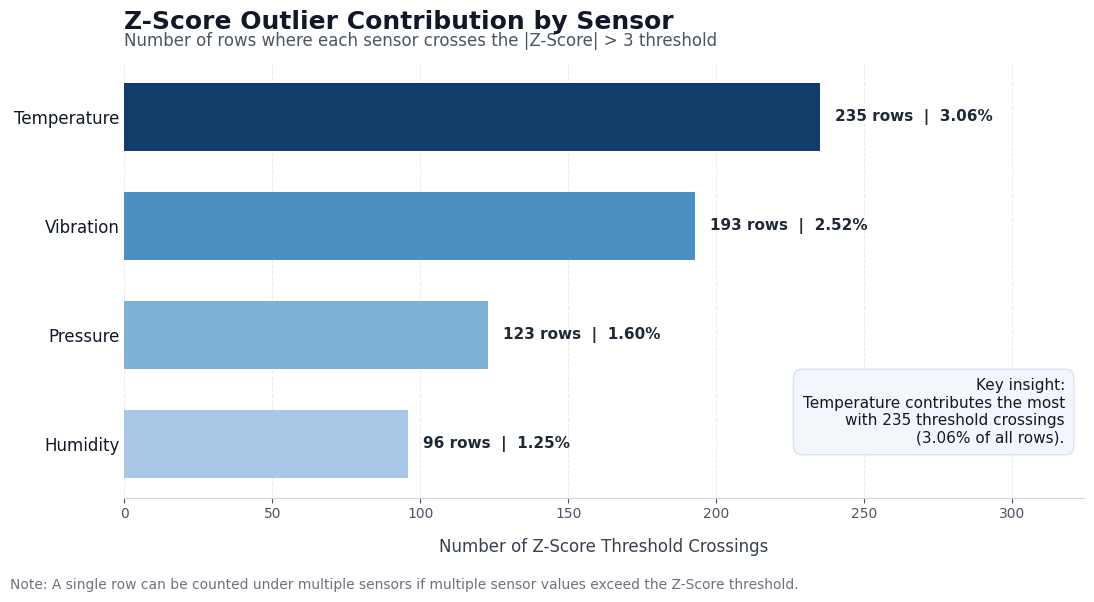

,sensor,outlier_count,outlier_percentage
3,Temperature,235,3.06
2,Vibration,193,2.52
1,Pressure,123,1.60
0,Humidity,96,1.25


In [19]:
# ============================================================
# Cell 3F: Z-Score outliers by sensor
# ============================================================

# Prepare chart data
outlier_contribution = (
    zscore_outlier_counts
    .reset_index()
    .rename(columns={"index": "sensor_zscore", 0: "outlier_count"})
)

outlier_contribution["sensor"] = (
    outlier_contribution["sensor_zscore"]
    .str.replace("_zscore", "", regex=False)
    .str.title()
)

outlier_contribution["outlier_percentage"] = (
    outlier_contribution["outlier_count"] / len(df_zscore) * 100
).round(2)

# Sort for horizontal ranking chart
outlier_contribution = outlier_contribution.sort_values(
    by="outlier_count",
    ascending=True
).reset_index(drop=True)

# ------------------------------------------------------------
# Build a polished horizontal bar chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

# Professional color palette
bar_colors = ["#A7C7E7", "#7FB3D5", "#4A90C2", "#123C69"]

# Draw bars
bars = ax.barh(
    outlier_contribution["sensor"],
    outlier_contribution["outlier_count"],
    color=bar_colors,
    edgecolor="none",
    height=0.62
)

# Add value labels
for bar, count, pct in zip(
    bars,
    outlier_contribution["outlier_count"],
    outlier_contribution["outlier_percentage"]
):
    ax.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count)} rows  |  {pct:.2f}%",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#1F2937"
    )

# Main title
ax.set_title(
    "Z-Score Outlier Contribution by Sensor",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=25,
    color="#111827"
)

# Subtitle
ax.text(
    0,
    1.04,
    "Number of rows where each sensor crosses the |Z-Score| > 3 threshold",
    transform=ax.transAxes,
    fontsize=12,
    color="#4B5563"
)

# Business insight annotation
top_sensor = outlier_contribution.iloc[-1]["sensor"]
top_count = int(outlier_contribution.iloc[-1]["outlier_count"])
top_pct = outlier_contribution.iloc[-1]["outlier_percentage"]

ax.text(
    0.98,
    0.12,
    f"Key insight:\n{top_sensor} contributes the most\nwith {top_count} threshold crossings\n({top_pct:.2f}% of all rows).",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=11,
    color="#111827",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#F3F7FB",
        edgecolor="#D6E4F0"
    )
)

# Axis labels
ax.set_xlabel(
    "Number of Z-Score Threshold Crossings",
    fontsize=12,
    color="#374151",
    labelpad=12
)
ax.set_ylabel("")

# Clean axis styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#D1D5DB")

ax.tick_params(axis="y", length=0, labelsize=12, colors="#111827")
ax.tick_params(axis="x", labelsize=10, colors="#4B5563")

# Subtle grid
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    alpha=0.25
)

ax.set_axisbelow(True)

# Add space for labels
ax.set_xlim(0, outlier_contribution["outlier_count"].max() * 1.38)

# Footer note
fig.text(
    0.01,
    0.01,
    "Note: A single row can be counted under multiple sensors if multiple sensor values exceed the Z-Score threshold.",
    fontsize=10,
    color="#6B7280"
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

# Show chart data
display(
    outlier_contribution
    .sort_values(by="outlier_count", ascending=False)
    [["sensor", "outlier_count", "outlier_percentage"]]
)

## Step 3G — Normal Rows vs Z-Score Outlier Rows

Now we create a summary chart showing how many rows were detected as Z-Score outliers.

This chart answers a simple business question:

**How large is the unusual group compared to the full dataset?**

A row is counted as an outlier if at least one sensor column has:

`absolute Z-Score > 3`

This chart helps us quickly communicate the overall scale of the anomaly problem.

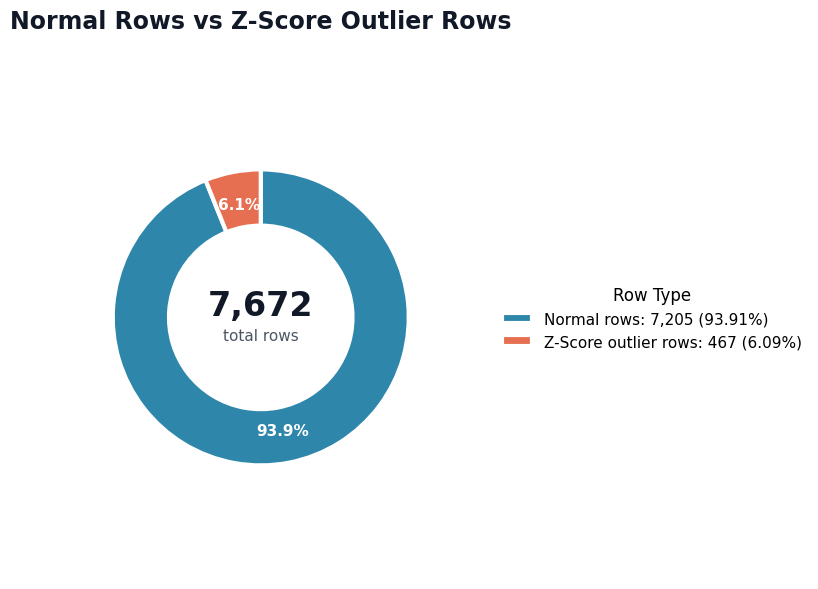

,row_type,row_count,percentage
0,Normal rows,7205,93.91
1,Z-Score outlier rows,467,6.09


In [21]:
# ============================================================
# Cell 3G: Professional donut chart - Normal vs Z-Score outliers
# ============================================================

# Count normal and outlier rows
normal_count = (~df_zscore["zscore_outlier"]).sum()
outlier_count = df_zscore["zscore_outlier"].sum()
total_count = len(df_zscore)

normal_pct = normal_count / total_count * 100
outlier_pct = outlier_count / total_count * 100

# Data for plotting
labels = ["Normal rows", "Z-Score outlier rows"]
counts = [normal_count, outlier_count]
percentages = [normal_pct, outlier_pct]

# ------------------------------------------------------------
# Create professional donut chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

colors = ["#2E86AB", "#E76F51"]

wedges, texts, autotexts = ax.pie(
    counts,
    labels=None,
    autopct=lambda pct: f"{pct:.1f}%",
    startangle=90,
    counterclock=False,
    colors=colors,
    pctdistance=0.78,
    wedgeprops={
        "width": 0.38,
        "edgecolor": "white",
        "linewidth": 3
    },
    textprops={
        "fontsize": 11,
        "fontweight": "bold",
        "color": "white"
    }
)

# Center text
ax.text(
    0,
    0.08,
    f"{total_count:,}",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold",
    color="#111827"
)

ax.text(
    0,
    -0.12,
    "total rows",
    ha="center",
    va="center",
    fontsize=11,
    color="#4B5563"
)

# Title
ax.set_title(
    "Normal Rows vs Z-Score Outlier Rows",
    fontsize=17,
    fontweight="bold",
    pad=20,
    color="#111827"
)

# Legend with counts and percentages
legend_labels = [
    f"Normal rows: {normal_count:,} ({normal_pct:.2f}%)",
    f"Z-Score outlier rows: {outlier_count:,} ({outlier_pct:.2f}%)"
]

ax.legend(
    wedges,
    legend_labels,
    title="Row Type",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

# Equal aspect ratio keeps donut circular
ax.axis("equal")

plt.tight_layout()
plt.show()

# Display summary table
outlier_summary = pd.DataFrame({
    "row_type": labels,
    "row_count": counts,
    "percentage": [round(p, 2) for p in percentages]
})

display(outlier_summary)

### Cell 3G Conclusion — Normal vs Z-Score Outlier Rows

The Z-Score method detected **467 outlier rows** out of **7,672 total rows**.

This means:

- **7,205 rows** are normal
- **467 rows** are Z-Score outliers
- **6.09%** of the dataset is statistically unusual according to the rule `absolute Z-Score > 3`

This gives us the overall scale of the anomaly problem.

Next, we will inspect the most important sensor visually.  
Since `temperature` contributed the highest number of Z-Score threshold crossings, we will create a professional boxplot for `temperature` and highlight its Z-Score outliers.

## Step 3H — Boxplot: Temperature Outliers

The exercise asks us to visualize a sensor column using a boxplot and mark outliers.

We choose `temperature` because it contributed the highest number of Z-Score outliers.

This chart helps us answer:

**Which temperature values are unusually high or low compared to the normal temperature range?**

In this chart:

- the box shows the normal middle range of temperature values
- the vertical reference lines show the Z-Score threshold boundaries
- red points show temperature values where `absolute temperature Z-Score > 3`

Sensor selected: temperature
Temperature outliers detected: 235
Lower Z-Score threshold: 22.32
Upper Z-Score threshold: 119.52


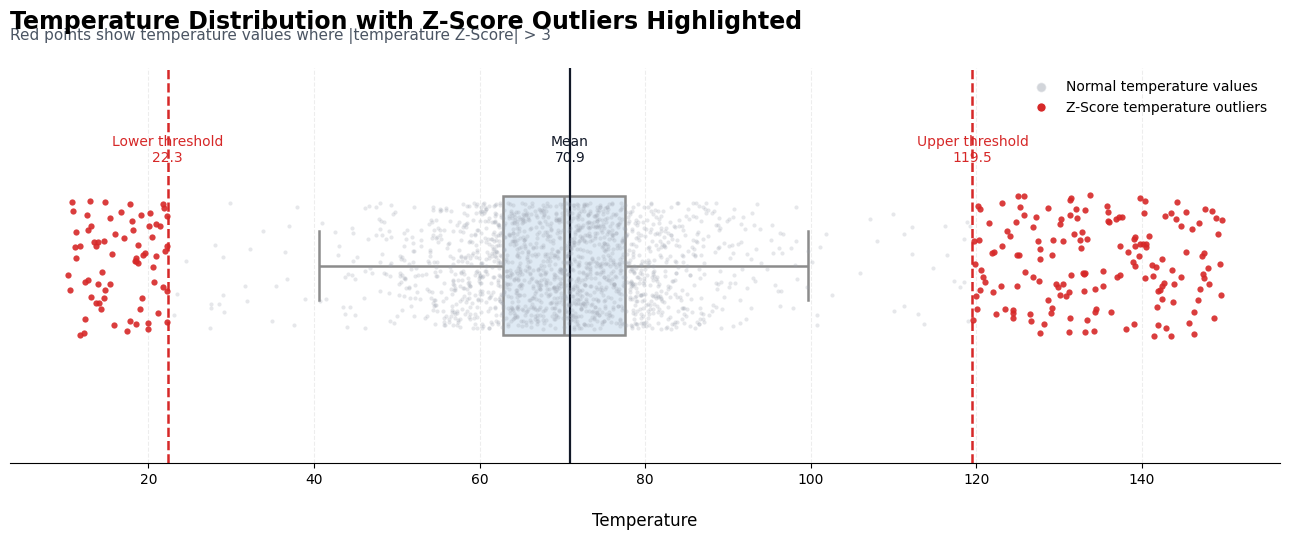

,temperature,temperature_zscore,pressure,vibration,humidity,equipment,location,faulty
1084,149.690420,4.862201,6.245383,2.869961,68.111290,Compressor,Atlanta,1.0
2199,149.480406,4.849237,17.682055,4.368772,77.115586,Turbine,Houston,1.0
3487,149.370088,4.842427,56.510062,3.033047,37.610409,Pump,New York,1.0
7322,149.162015,4.829583,73.430234,2.327238,26.237577,Pump,Atlanta,1.0
7,148.923369,4.814852,22.214121,0.109819,39.944953,Turbine,San Francisco,1.0
2023,148.705580,4.801409,28.584577,3.298497,24.053289,Compressor,New York,1.0
5125,148.449170,4.785581,49.425503,2.479831,38.046372,Pump,New York,1.0
7320,148.132522,4.766035,35.576462,2.547147,48.535884,Turbine,San Francisco,1.0
6191,147.993132,4.757430,63.680625,2.072083,36.144701,Compressor,Chicago,1.0
6273,147.589537,4.732517,55.727569,2.747801,73.937247,Pump,Chicago,1.0


In [23]:
# ============================================================
# Cell 3H v2: Clean professional boxplot - Temperature outliers
# ============================================================

sensor = "temperature"
sensor_zscore = "temperature_zscore"

# Flag temperature-specific Z-Score outliers
temperature_outlier_flag = df_zscore[sensor_zscore].abs() > Z_SCORE_THRESHOLD

# Calculate mean and Z-Score threshold boundaries in original temperature scale
temperature_mean = df_zscore[sensor].mean()
temperature_std = df_zscore[sensor].std()

lower_threshold = temperature_mean - Z_SCORE_THRESHOLD * temperature_std
upper_threshold = temperature_mean + Z_SCORE_THRESHOLD * temperature_std

# Split normal and outlier values
normal_temperature = df_zscore.loc[~temperature_outlier_flag, sensor]
outlier_temperature = df_zscore.loc[temperature_outlier_flag, sensor]

print(f"Sensor selected: {sensor}")
print(f"Temperature outliers detected: {temperature_outlier_flag.sum()}")
print(f"Lower Z-Score threshold: {lower_threshold:.2f}")
print(f"Upper Z-Score threshold: {upper_threshold:.2f}")

# To avoid overcrowding the chart, we sample normal points for display only.
# The outlier calculation still uses the full dataset.
normal_temperature_sample = normal_temperature.sample(
    n=min(1800, len(normal_temperature)),
    random_state=RANDOM_STATE
)

# ------------------------------------------------------------
# Create professional chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 5.5))

# Main boxplot
sns.boxplot(
    x=df_zscore[sensor],
    ax=ax,
    showfliers=False,
    color="#DCEAF7",
    linewidth=1.8,
    width=0.35
)

# Normal points - light grey
sns.stripplot(
    x=normal_temperature_sample,
    ax=ax,
    color="#9CA3AF",
    alpha=0.25,
    size=3,
    jitter=0.16
)

# Outlier points - red
sns.stripplot(
    x=outlier_temperature,
    ax=ax,
    color="#D62828",
    alpha=0.90,
    size=4.5,
    jitter=0.18
)

# Threshold lines
ax.axvline(
    lower_threshold,
    color="#D62828",
    linestyle="--",
    linewidth=1.8
)

ax.axvline(
    upper_threshold,
    color="#D62828",
    linestyle="--",
    linewidth=1.8
)

# Mean line
ax.axvline(
    temperature_mean,
    color="#111827",
    linestyle="-",
    linewidth=1.6
)

# Title
ax.set_title(
    "Temperature Distribution with Z-Score Outliers Highlighted",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=28
)

# Subtitle
ax.text(
    0,
    1.07,
    "Red points show temperature values where |temperature Z-Score| > 3",
    transform=ax.transAxes,
    fontsize=11,
    color="#4B5563"
)

# Threshold labels placed clearly below the plot area
ax.text(
    lower_threshold,
    -0.33,
    f"Lower threshold\n{lower_threshold:.1f}",
    ha="center",
    va="top",
    fontsize=10,
    color="#D62828"
)

ax.text(
    upper_threshold,
    -0.33,
    f"Upper threshold\n{upper_threshold:.1f}",
    ha="center",
    va="top",
    fontsize=10,
    color="#D62828"
)

ax.text(
    temperature_mean,
    -0.33,
    f"Mean\n{temperature_mean:.1f}",
    ha="center",
    va="top",
    fontsize=10,
    color="#111827"
)

# Labels
ax.set_xlabel("Temperature", fontsize=12, labelpad=18)
ax.set_ylabel("")

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", linestyle="--", alpha=0.22)
ax.tick_params(axis="y", length=0, labelleft=False)

# Add legend manually
normal_marker = plt.Line2D(
    [0], [0],
    marker="o",
    color="w",
    label="Normal temperature values",
    markerfacecolor="#9CA3AF",
    markersize=7,
    alpha=0.45
)

outlier_marker = plt.Line2D(
    [0], [0],
    marker="o",
    color="w",
    label="Z-Score temperature outliers",
    markerfacecolor="#D62828",
    markersize=7
)

ax.legend(
    handles=[normal_marker, outlier_marker],
    loc="upper right",
    frameon=False,
    fontsize=10
)

plt.tight_layout()
plt.show()

# Show strongest temperature outliers
display(
    df_zscore.loc[
        temperature_outlier_flag,
        [
            "temperature",
            "temperature_zscore",
            "pressure",
            "vibration",
            "humidity",
            "equipment",
            "location",
            "faulty"
        ]
    ]
    .sort_values("temperature_zscore", key=lambda x: x.abs(), ascending=False)
    .head(10)
)

### Cell 3H Conclusion — Temperature Outliers Visualized

The temperature boxplot shows the distribution of normal and unusual temperature readings.

The average temperature is approximately **70.9**.

Using the Z-Score rule `|temperature Z-Score| > 3`, temperature values below approximately **22.3** or above approximately **119.5** are marked as statistical outliers.

In the chart:

- grey points represent normal temperature readings
- red points represent temperature-based Z-Score outliers
- the dashed red lines show the lower and upper Z-Score thresholds
- the dark vertical line shows the mean temperature

The chart shows that temperature outliers exist on both sides:

- very low temperature readings below the lower threshold
- very high temperature readings above the upper threshold

This confirms that temperature is one of the strongest contributors to statistical outliers in the dataset.

However, these rows should not be deleted automatically.  
They may represent sensor errors, abnormal equipment behavior, or real fault conditions.

Next, we will create a Z-Score distribution chart to compare the Z-Score patterns across all sensor columns.

## Step 3I — Z-Score Distribution Across Sensors

Now we visualize the Z-Score distribution for all sensor columns.

This chart helps us answer:

**How are the sensor values distributed after standardization?**

A Z-Score near `0` means the value is close to the average.  
A Z-Score beyond `-3` or `+3` means the value is statistically unusual.

In this chart:

- each curve shows one sensor's Z-Score distribution
- the vertical dashed lines show the outlier threshold at `-3` and `+3`
- values outside these lines are considered statistical outliers

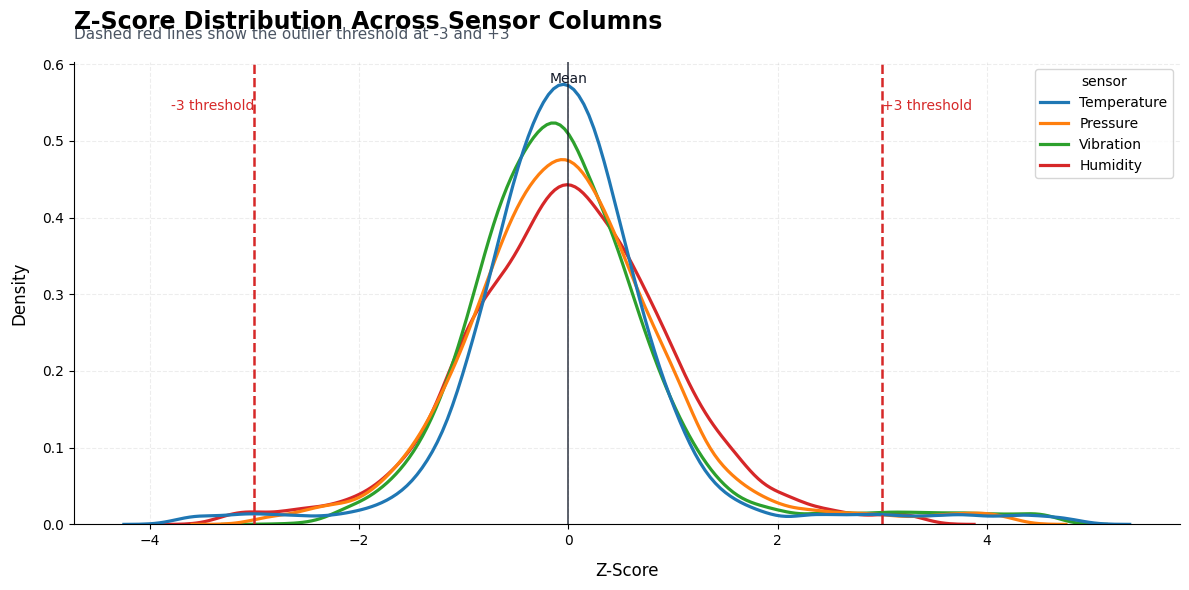

,min,max
Temperature,-3.744004,4.862201
Pressure,-3.093673,4.252689
Vibration,-2.800039,4.637542
Humidity,-3.361193,3.375266


In [24]:
# ============================================================
# Cell 3I: Professional chart - Z-Score distributions by sensor
# ============================================================

# Convert Z-Score columns from wide format to long format.
# This makes the data easier to plot with seaborn.
zscore_long = df_zscore[z_score_columns].melt(
    var_name="sensor",
    value_name="z_score"
)

# Clean sensor names for display.
zscore_long["sensor"] = (
    zscore_long["sensor"]
    .str.replace("_zscore", "", regex=False)
    .str.title()
)

# ------------------------------------------------------------
# Create professional KDE distribution chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

sns.kdeplot(
    data=zscore_long,
    x="z_score",
    hue="sensor",
    fill=False,
    linewidth=2.3,
    common_norm=False,
    ax=ax
)

# Add Z-Score threshold lines
ax.axvline(
    -Z_SCORE_THRESHOLD,
    color="#D62828",
    linestyle="--",
    linewidth=1.8
)

ax.axvline(
    Z_SCORE_THRESHOLD,
    color="#D62828",
    linestyle="--",
    linewidth=1.8
)

# Add zero line
ax.axvline(
    0,
    color="#111827",
    linestyle="-",
    linewidth=1.2,
    alpha=0.8
)

# Title and subtitle
ax.set_title(
    "Z-Score Distribution Across Sensor Columns",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=24
)

ax.text(
    0,
    1.05,
    "Dashed red lines show the outlier threshold at -3 and +3",
    transform=ax.transAxes,
    fontsize=11,
    color="#4B5563"
)

# Labels
ax.set_xlabel("Z-Score", fontsize=12, labelpad=10)
ax.set_ylabel("Density", fontsize=12, labelpad=10)

# Threshold labels
ax.text(
    -Z_SCORE_THRESHOLD,
    ax.get_ylim()[1] * 0.92,
    "-3 threshold",
    ha="right",
    va="top",
    fontsize=10,
    color="#D62828"
)

ax.text(
    Z_SCORE_THRESHOLD,
    ax.get_ylim()[1] * 0.92,
    "+3 threshold",
    ha="left",
    va="top",
    fontsize=10,
    color="#D62828"
)

ax.text(
    0,
    ax.get_ylim()[1] * 0.98,
    "Mean",
    ha="center",
    va="top",
    fontsize=10,
    color="#111827"
)

# Clean formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="both", linestyle="--", alpha=0.22)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Show quick summary of extreme Z-Scores by sensor
zscore_range_summary = df_zscore[z_score_columns].agg(["min", "max"]).T
zscore_range_summary.index = (
    zscore_range_summary.index
    .str.replace("_zscore", "", regex=False)
    .str.title()
)

display(zscore_range_summary)

### Cell 3I Conclusion — Z-Score Distribution Across Sensors

The Z-Score distribution chart shows that all sensor columns are centered around **0**, which is expected after standardization.

Most observations fall between the threshold range of **-3 and +3**, meaning most sensor readings are statistically normal.

The dashed red lines mark the Z-Score outlier boundaries:

- values below **-3** are unusually low
- values above **+3** are unusually high

The chart confirms that only the tail regions of the distributions are treated as statistical outliers.

Temperature and vibration show visible extreme tail behavior, which supports the earlier finding that these two sensors contribute the highest number of Z-Score outlier cases.

This chart is useful because it shows not only how many outliers exist, but also how the full sensor distributions behave after standardization.

## Step 3J — Scatter Plot: Temperature vs Vibration

Temperature and vibration are the two strongest contributors to Z-Score outliers.

In this step, we visualize both sensors together in a 2D scatter plot.

This chart helps us answer:

**Do Z-Score outliers appear as visibly separate points in sensor space?**

In the chart:

- grey points represent normal rows
- red points represent rows marked as Z-Score outliers
- the x-axis shows `temperature`
- the y-axis shows `vibration`

Normal rows: 7,205
Z-Score outlier rows: 467


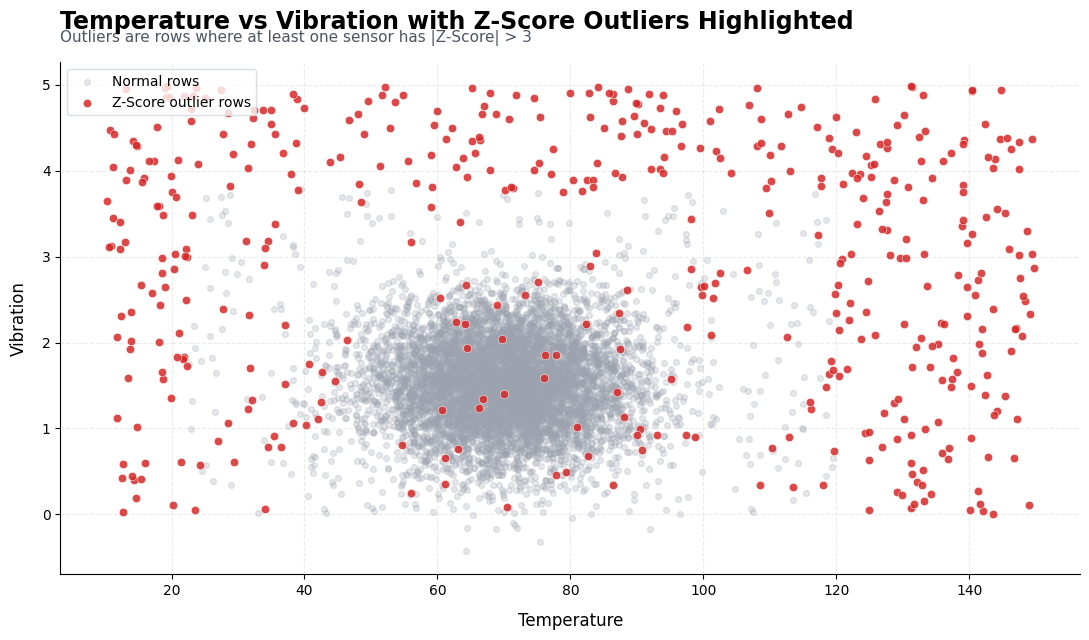

In [25]:
# ============================================================
# Cell 3J: Professional scatter plot - Temperature vs Vibration
# ============================================================

# Split the data into normal rows and Z-Score outlier rows.
normal_rows = df_zscore[~df_zscore["zscore_outlier"]]
outlier_rows = df_zscore[df_zscore["zscore_outlier"]]

print(f"Normal rows: {len(normal_rows):,}")
print(f"Z-Score outlier rows: {len(outlier_rows):,}")

# ------------------------------------------------------------
# Create professional scatter plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6.5))

# Plot normal rows in light grey.
ax.scatter(
    normal_rows["temperature"],
    normal_rows["vibration"],
    s=18,
    alpha=0.25,
    color="#9CA3AF",
    label="Normal rows"
)

# Plot outlier rows in red.
ax.scatter(
    outlier_rows["temperature"],
    outlier_rows["vibration"],
    s=36,
    alpha=0.85,
    color="#D62828",
    edgecolor="white",
    linewidth=0.4,
    label="Z-Score outlier rows"
)

# Title and subtitle
ax.set_title(
    "Temperature vs Vibration with Z-Score Outliers Highlighted",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=24
)

ax.text(
    0,
    1.04,
    "Outliers are rows where at least one sensor has |Z-Score| > 3",
    transform=ax.transAxes,
    fontsize=11,
    color="#4B5563"
)

# Axis labels
ax.set_xlabel("Temperature", fontsize=12, labelpad=10)
ax.set_ylabel("Vibration", fontsize=12, labelpad=10)

# Clean formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="both", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

# Legend
ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#D1D5DB",
    fontsize=10,
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Cell 3J Conclusion — Temperature vs Vibration Outlier Pattern

The scatter plot compares `temperature` and `vibration`, the two strongest contributors to Z-Score outliers.

The normal rows form a dense central cloud, which represents the usual operating range of the equipment.

The Z-Score outlier rows appear mostly around the edges of the plot.  
This means many outliers are associated with:

- very low temperature
- very high temperature
- unusually high vibration
- unusual combinations of temperature and vibration

This visual pattern supports the Z-Score results from the previous steps.

From an industrial monitoring perspective, rows with unusual temperature and vibration values should be inspected carefully because they may indicate abnormal equipment behavior, possible sensor issues, or early fault signals.

Next, we will create a heatmap for the strongest Z-Score outlier rows to understand which sensors are abnormal together.

## Step 3K — Heatmap: Strongest Z-Score Outlier Rows

Now we inspect the strongest Z-Score outlier rows in more detail.

A heatmap helps us answer:

**Which sensors are abnormal together in the same rows?**

In this chart:

- each row represents one detected outlier row
- each column represents one sensor
- the color intensity represents the Z-Score value
- stronger colors mean stronger abnormal behavior

To keep the chart readable, we only show the top strongest outlier rows based on their maximum absolute Z-Score.

Number of detected Z-Score outlier rows: 467
Showing top 20 strongest outlier rows by maximum absolute Z-Score.


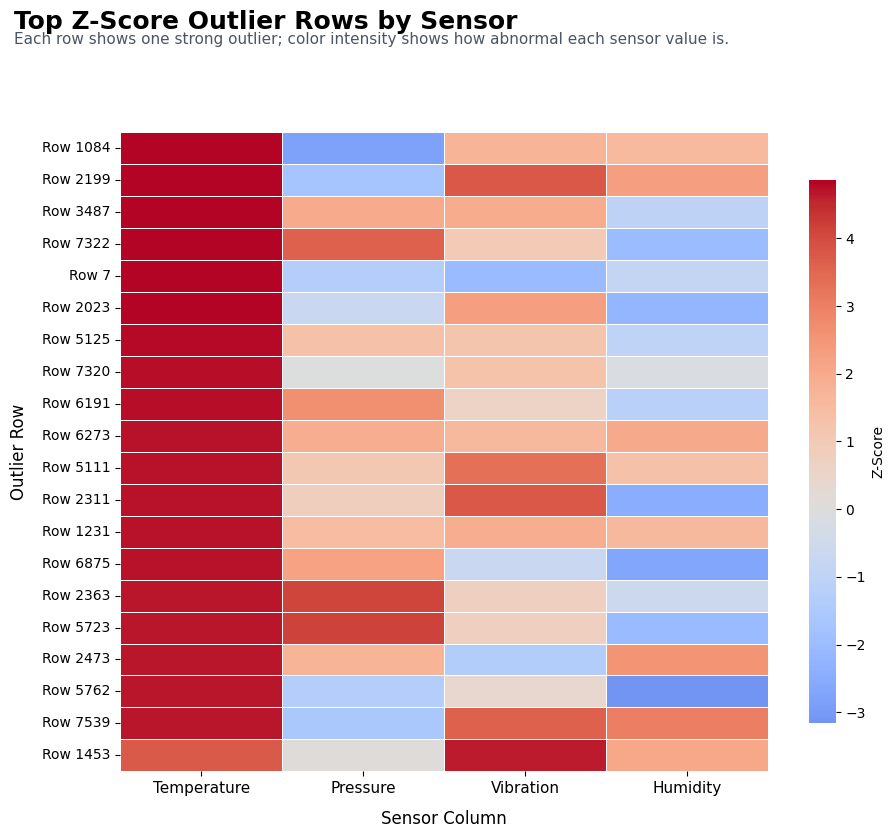

,temperature,pressure,vibration,humidity,temperature_zscore,pressure_zscore,vibration_zscore,humidity_zscore,max_abs_zscore,equipment,location,faulty
1084,149.690420,6.245383,2.869961,68.111290,4.862201,-2.840861,1.726903,1.528079,4.862201,Compressor,Atlanta,1.0
2199,149.480406,17.682055,4.368772,77.115586,4.849237,-1.739231,3.784126,2.288482,4.849237,Turbine,Houston,1.0
3487,149.370088,56.510062,3.033047,37.610409,4.842427,2.000850,1.950749,-1.047687,4.842427,Pump,New York,1.0
7322,149.162015,73.430234,2.327238,26.237577,4.829583,3.630675,0.981976,-2.008110,4.829583,Pump,Atlanta,1.0
7,148.923369,22.214121,0.109819,39.944953,4.814852,-1.302683,-2.061587,-0.850537,4.814852,Turbine,San Francisco,1.0
2023,148.705580,28.584577,3.298497,24.053289,4.801409,-0.689053,2.315098,-2.192571,4.801409,Compressor,New York,1.0
5125,148.449170,49.425503,2.479831,38.046372,4.785581,1.318435,1.191421,-1.010870,4.785581,Pump,New York,1.0
7320,148.132522,35.576462,2.547147,48.535884,4.766035,-0.015565,1.283817,-0.125043,4.766035,Turbine,San Francisco,1.0
6191,147.993132,63.680625,2.072083,36.144701,4.757430,2.691550,0.631758,-1.171465,4.757430,Compressor,Chicago,1.0
6273,147.589537,55.727569,2.747801,73.937247,4.732517,1.925477,1.559229,2.020075,4.732517,Pump,Chicago,1.0


In [27]:
# ============================================================
# Cell 3K v2: Clean professional heatmap - strongest Z-Score outlier rows
# ============================================================

# Select only rows detected as Z-Score outliers
outlier_only = df_zscore[df_zscore["zscore_outlier"]].copy()

# Calculate the strongest absolute Z-Score per row
outlier_only["max_abs_zscore"] = outlier_only[z_score_columns].abs().max(axis=1)

# Keep fewer rows so the chart stays readable
TOP_N = 20

top_outliers = (
    outlier_only
    .sort_values("max_abs_zscore", ascending=False)
    .head(TOP_N)
)

# Prepare heatmap data
heatmap_data = top_outliers[z_score_columns].copy()

# Clean column names
heatmap_data.columns = (
    heatmap_data.columns
    .str.replace("_zscore", "", regex=False)
    .str.title()
)

# Use original row numbers as row labels
heatmap_data.index = [f"Row {idx}" for idx in heatmap_data.index]

print(f"Number of detected Z-Score outlier rows: {len(outlier_only)}")
print(f"Showing top {TOP_N} strongest outlier rows by maximum absolute Z-Score.")

# ------------------------------------------------------------
# Create clean professional heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9.5, 8.5))

sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    center=0,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={
        "label": "Z-Score",
        "shrink": 0.85
    },
    ax=ax
)

# Main title
fig.suptitle(
    "Top Z-Score Outlier Rows by Sensor",
    fontsize=18,
    fontweight="bold",
    x=0.02,
    y=0.98,
    ha="left"
)

# Subtitle
fig.text(
    0.02,
    0.94,
    "Each row shows one strong outlier; color intensity shows how abnormal each sensor value is.",
    fontsize=11,
    color="#4B5563",
    ha="left"
)

# Axis labels
ax.set_xlabel("Sensor Column", fontsize=12, labelpad=10)
ax.set_ylabel("Outlier Row", fontsize=12, labelpad=10)

# Tick label styling
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=10)

# Improve spacing so title does not overlap
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

# Display matching table
display(
    top_outliers[
        sensor_columns + z_score_columns + ["max_abs_zscore", "equipment", "location", "faulty"]
    ]
)

### Cell 3K Conclusion — Strongest Z-Score Outlier Rows

The heatmap shows the strongest Z-Score outlier rows across the four sensor columns.

Each row represents one detected outlier row, and each column represents one sensor:

- `temperature`
- `pressure`
- `vibration`
- `humidity`

The colors show the direction and strength of the abnormal value:

- red means the sensor value is unusually high
- blue means the sensor value is unusually low
- stronger color intensity means a stronger Z-Score

The heatmap shows that many of the strongest outlier rows are mainly driven by high `temperature` values.  
Some rows are also strongly affected by `vibration`, while pressure and humidity show mixed behavior.

This is useful because it tells us not only which rows are outliers, but also **which sensors are responsible** for the abnormal pattern.

From an industrial monitoring perspective, rows with multiple strong sensor deviations should be inspected carefully because they may indicate more serious equipment issues.

## Step 3L — Remove Z-Score Outlier Rows

Now we create a cleaned version of the dataset by removing rows marked as Z-Score outliers.

Important:

We do not overwrite the original dataset.

Instead, we create a new dataframe:

`df_zscore_clean`

This keeps our workflow safe because:

- `df` remains the original dataset
- `df_zscore` contains the original data plus Z-Score columns
- `df_zscore_clean` contains only rows that were not marked as Z-Score outliers

This step helps us prepare for the final beginner task:

**Compare mean and standard deviation before and after removing outliers.**

In [28]:
# ============================================================
# Cell 3L: Remove Z-Score outlier rows
# ============================================================

# Keep only rows that are NOT marked as Z-Score outliers.
# zscore_outlier == False means the row is statistically normal
# according to the rule |Z-Score| > 3.
df_zscore_clean = df_zscore[df_zscore["zscore_outlier"] == False].copy()

# Count rows before and after removing outliers
rows_before = len(df_zscore)
rows_after = len(df_zscore_clean)
rows_removed = rows_before - rows_after
removed_percentage = rows_removed / rows_before * 100

print("Z-Score outlier removal completed.")
print(f"Rows before removal: {rows_before:,}")
print(f"Rows after removal: {rows_after:,}")
print(f"Rows removed: {rows_removed:,}")
print(f"Percentage removed: {removed_percentage:.2f}%")

# Preview cleaned dataset
display(df_zscore_clean.head())

Z-Score outlier removal completed.
Rows before removal: 7,672
Rows after removal: 7,205
Rows removed: 467
Percentage removed: 6.09%


,temperature,pressure,vibration,humidity,equipment,location,faulty,temperature_zscore,pressure_zscore,vibration_zscore,humidity_zscore,zscore_outlier
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0,-0.786559,-1.031515,-1.379835,-0.364960,False
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0,0.297421,-1.231413,0.996878,-0.688188,False
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0,0.026921,-0.815021,-0.305549,0.754790,False
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0,0.042871,-0.336666,0.218075,-0.798163,False
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0,-0.272570,0.911173,-1.738238,-0.571109,False


### Cell 3L Conclusion — Z-Score Outliers Removed

A cleaned dataframe named `df_zscore_clean` was created by removing rows where `zscore_outlier = True`.

The original working dataframe `df_zscore` was not overwritten, which keeps the workflow safe and reproducible.

After removing the Z-Score outliers:

- the original dataset had **7,672 rows**
- the cleaned dataset has **7,205 rows**
- **467 rows** were removed
- this equals **6.09%** of the dataset

The preview confirms that the cleaned dataframe contains only rows where `zscore_outlier = False`.

This cleaned dataset will be used only for comparison purposes.  
We should not assume that all removed rows are bad data because some may represent real abnormal equipment behavior.

Next, we will compare the mean and standard deviation before and after removing Z-Score outliers.

## Step 3M — Compare Mean and Standard Deviation Before and After Removing Outliers

Now we compare the sensor statistics before and after removing Z-Score outliers.

This step answers:

**How did removing statistical outliers change the dataset?**

We compare two key statistics:

1. **Mean** — the average sensor value
2. **Standard deviation** — how spread out the sensor values are

If outliers strongly affect the dataset, we usually expect the standard deviation to decrease after removing them.

This comparison is important because it shows the practical impact of outlier removal on the sensor data.

## Step 3M — Compare Mean and Standard Deviation Before and After Removing Outliers

Now we compare the sensor statistics before and after removing Z-Score outliers.

This step answers:

**How did removing statistical outliers change the dataset?**

We compare two key statistics:

1. **Mean** — the average sensor value
2. **Standard deviation** — how spread out the sensor values are

If outliers strongly affect the dataset, we usually expect the standard deviation to decrease after removing them.

This comparison is important because it shows the practical impact of outlier removal on the sensor data.

In [30]:
# ============================================================
# Cell 3M: Compare mean and standard deviation before vs after
# ============================================================

# Calculate mean and standard deviation before removing outliers
stats_before = df_zscore[sensor_columns].agg(["mean", "std"]).T

# Calculate mean and standard deviation after removing outliers
stats_after = df_zscore_clean[sensor_columns].agg(["mean", "std"]).T

# Rename columns clearly
stats_before.columns = ["mean_before", "std_before"]
stats_after.columns = ["mean_after", "std_after"]

# Combine before and after statistics
stats_comparison = pd.concat([stats_before, stats_after], axis=1)

# Calculate changes
stats_comparison["mean_change"] = (
    stats_comparison["mean_after"] - stats_comparison["mean_before"]
)

stats_comparison["std_change"] = (
    stats_comparison["std_after"] - stats_comparison["std_before"]
)

stats_comparison["std_change_pct"] = (
    stats_comparison["std_change"] / stats_comparison["std_before"] * 100
).round(2)

# Round values for clean display
stats_comparison = stats_comparison.round(3)

print("Mean and standard deviation comparison:")
display(stats_comparison)

Mean and standard deviation comparison:


,mean_before,std_before,mean_after,std_after,mean_change,std_change,std_change_pct
temperature,70.922,16.200,70.012,11.433,-0.911,-4.767,-29.42
pressure,35.738,10.382,35.067,8.635,-0.671,-1.747,-16.82
vibration,1.612,0.729,1.526,0.548,-0.086,-0.181,-24.84
humidity,50.017,11.841,50.050,10.447,0.034,-1.394,-11.77


### Cell 3M Conclusion — Impact of Removing Z-Score Outliers

After removing the Z-Score outlier rows, the mean and standard deviation changed across all sensor columns.

The most important change is in the **standard deviation**:

- `temperature` standard deviation decreased by **29.42%**
- `vibration` standard deviation decreased by **24.84%**
- `pressure` standard deviation decreased by **16.82%**
- `humidity` standard deviation decreased by **11.77%**

This means the outlier rows had a strong effect on the spread of the sensor values.

`temperature` was affected the most.  
Its standard deviation dropped from **16.20** to **11.43**, showing that extreme temperature readings were making the original dataset much more variable.

The means changed only slightly compared to the standard deviations.  
This suggests that the main impact of the outliers was on the **spread** of the data rather than dramatically shifting the average.

Overall, removing Z-Score outliers made the dataset more statistically stable.

However, in an industrial monitoring context, these removed rows should still be investigated before being discarded permanently because they may represent real abnormal equipment behavior or early warning signs.

### Cell 3M Conclusion — Impact of Removing Z-Score Outliers

After removing the Z-Score outlier rows, the mean and standard deviation changed across all sensor columns.

The most important change is in the **standard deviation**:

- `temperature` standard deviation decreased by **29.42%**
- `vibration` standard deviation decreased by **24.84%**
- `pressure` standard deviation decreased by **16.82%**
- `humidity` standard deviation decreased by **11.77%**

This means the outlier rows had a strong effect on the spread of the sensor values.

`temperature` was affected the most.  
Its standard deviation dropped from **16.20** to **11.43**, showing that extreme temperature readings were making the original dataset much more variable.

The means changed only slightly compared to the standard deviations.  
This suggests that the main impact of the outliers was on the **spread** of the data rather than dramatically shifting the average.

Overall, removing Z-Score outliers made the dataset more statistically stable.

However, in an industrial monitoring context, these removed rows should still be investigated before being discarded permanently because they may represent real abnormal equipment behavior or early warning signs.

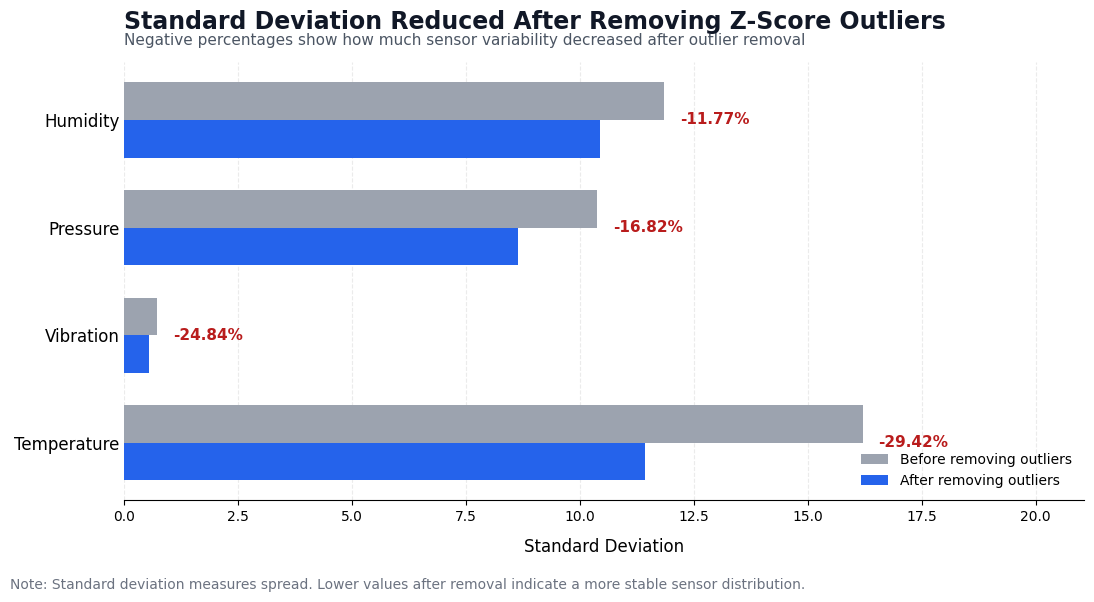

,sensor,std_before,std_after,std_change_pct
0,Temperature,16.200,11.433,-29.42
1,Vibration,0.729,0.548,-24.84
2,Pressure,10.382,8.635,-16.82
3,Humidity,11.841,10.447,-11.77


In [31]:
# ============================================================
# Cell 3N: Professional chart - Standard deviation before vs after
# ============================================================

# Prepare chart data from the stats comparison table
std_comparison = (
    stats_comparison[["std_before", "std_after", "std_change_pct"]]
    .reset_index()
    .rename(columns={"index": "sensor"})
)

# Clean sensor names for display
std_comparison["sensor"] = std_comparison["sensor"].str.title()

# Sort by biggest standard deviation reduction
std_comparison = std_comparison.sort_values(
    by="std_change_pct",
    ascending=True
).reset_index(drop=True)

# ------------------------------------------------------------
# Create grouped horizontal bar chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

# Y positions
y_positions = np.arange(len(std_comparison))
bar_height = 0.35

# Colors
before_color = "#9CA3AF"
after_color = "#2563EB"
text_color = "#111827"

# Plot standard deviation before and after
ax.barh(
    y_positions + bar_height / 2,
    std_comparison["std_before"],
    height=bar_height,
    color=before_color,
    label="Before removing outliers"
)

ax.barh(
    y_positions - bar_height / 2,
    std_comparison["std_after"],
    height=bar_height,
    color=after_color,
    label="After removing outliers"
)

# Add percentage reduction labels
for i, row in std_comparison.iterrows():
    max_value = max(row["std_before"], row["std_after"])
    ax.text(
        max_value + 0.35,
        i,
        f'{row["std_change_pct"]:.2f}%',
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#B91C1C"
    )

# Y-axis labels
ax.set_yticks(y_positions)
ax.set_yticklabels(std_comparison["sensor"], fontsize=12)

# Title and subtitle
ax.set_title(
    "Standard Deviation Reduced After Removing Z-Score Outliers",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=24,
    color=text_color
)

ax.text(
    0,
    1.04,
    "Negative percentages show how much sensor variability decreased after outlier removal",
    transform=ax.transAxes,
    fontsize=11,
    color="#4B5563"
)

# Axis labels
ax.set_xlabel("Standard Deviation", fontsize=12, labelpad=10)
ax.set_ylabel("")

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.tick_params(axis="y", length=0)
ax.set_axisbelow(True)

# Legend
ax.legend(
    frameon=False,
    fontsize=10,
    loc="lower right"
)

# Add space for labels
ax.set_xlim(0, std_comparison["std_before"].max() * 1.30)

# Footer note
fig.text(
    0.01,
    0.01,
    "Note: Standard deviation measures spread. Lower values after removal indicate a more stable sensor distribution.",
    fontsize=10,
    color="#6B7280"
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

display(std_comparison)

### Cell 3N Conclusion — Standard Deviation Before vs After Outlier Removal

The chart confirms that removing Z-Score outliers reduced the standard deviation for every sensor column.

This means the cleaned dataset became less spread out and more statistically stable.

The largest reduction happened in:

- `temperature`: **-29.42%**
- `vibration`: **-24.84%**
- `pressure`: **-16.82%**
- `humidity`: **-11.77%**

This supports the earlier finding that `temperature` and `vibration` were the strongest contributors to statistical outliers.

From a machine monitoring perspective, this tells us that unusual temperature and vibration readings were increasing the variability of the dataset the most.

However, lower variability does not automatically mean the removed rows were bad data.  
Some removed rows may still represent real equipment faults or abnormal operating conditions.

Therefore, outlier removal should always be treated as an analytical decision, not an automatic cleaning rule.